<a href="https://www.kaggle.com/code/asfarhossainsitab/facial-emotion-recognition?scriptVersionId=318739053" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# 😊 Facial Emotion Recognition — RAF-DB Complete Pipeline
**Dataset:** [shuvoalok/raf-db-dataset](https://www.kaggle.com/datasets/shuvoalok/raf-db-dataset)

RAF-DB (Real-world Affective Faces Database) contains **12,271 training** and **3,068 test** aligned facial images pre-labelled into 7 basic emotions.

This notebook covers:
1. EDA & Data Visualization
2. Data Preprocessing & Augmentation
3. **Normal Models** — HOG+SVM, Simple CNN, Deep CNN with Residual Blocks
4. **Advanced Models** — ResNet50, EfficientNetB3, Vision Transformer (ViT), Ensemble
5. Training, Evaluation & Comparison

**Classes:** Surprise | Fear | Disgust | Happiness | Sadness | Anger | Neutral

**RAF-DB Label Map:**
| Folder | Emotion |
|--------|---------|
| 1 | Surprise |
| 2 | Fear |
| 3 | Disgust |
| 4 | Happiness |
| 5 | Sadness |
| 6 | Anger |
| 7 | Neutral |

## 📦 1. Install & Import

In [1]:
!pip install -q timm torchinfo grad-cam seaborn scikit-learn opencv-python-headless

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.8/7.8 MB 59.5 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
import os, random, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path
from PIL import Image
from collections import Counter

import cv2
from skimage.feature import hog
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (classification_report, confusion_matrix,
                              ConfusionMatrixDisplay, accuracy_score)
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset, WeightedRandomSampler
from torchvision import datasets, transforms, models
from torchinfo import summary

import timm  # for ViT and EfficientNet

warnings.filterwarnings("ignore")
sns.set_style("whitegrid")
plt.rcParams["figure.dpi"] = 120

# ---------- reproducibility ----------
SEED = 42
random.seed(SEED); np.random.seed(SEED)
torch.manual_seed(SEED); torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    torch.backends.cudnn.benchmark = True
    torch.backends.cudnn.deterministic = False

Device: cuda
GPU: Tesla T4


## 📂 2. Dataset Paths (RAF-DB)

RAF-DB is already split into  and  directories, each containing subfolders – corresponding to the 7 emotion classes.
No re-organisation is needed —  works directly on the numeric subfolders.
We also load the CSV label files for reference and class-imbalance analysis.

In [3]:
# ── RAF-DB paths (Kaggle) ──
BASE_DIR  = Path("/kaggle/input/datasets/shuvoalok/raf-db-dataset")
TRAIN_DIR = BASE_DIR / "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/train"
TEST_DIR  = BASE_DIR / "/kaggle/input/datasets/shuvoalok/raf-db-dataset/DATASET/test"

# Verify structure
assert TRAIN_DIR.exists(), f"Train dir not found: {TRAIN_DIR}"
assert TEST_DIR.exists(),  f"Test dir not found: {TEST_DIR}"

# ── RAF-DB label mapping: folder name → emotion ──
LABEL_MAP = {
    "1": "Surprise",
    "2": "Fear",
    "3": "Disgust",
    "4": "Happiness",
    "5": "Sadness",
    "6": "Anger",
    "7": "Neutral",
}

# Class list ordered 1–7 (must match ImageFolder alphabetical sort of "1".."7")
CLASSES     = [LABEL_MAP[str(i)] for i in range(1, 8)]
NUM_CLASSES = 7
CLASS2IDX   = {c: i for i, c in enumerate(CLASSES)}
IDX2CLASS   = {i: c for c, i in CLASS2IDX.items()}

print(f"Classes ({NUM_CLASSES}): {CLASSES}")
print("Train dir contents:", sorted([p.name for p in TRAIN_DIR.iterdir()]))
print("Test  dir contents:", sorted([p.name for p in TEST_DIR.iterdir()]))

# ── Load CSV labels for reference ──
CSV_DIR = BASE_DIR.parent  # CSVs are one level up from DATASET/
train_df = pd.read_csv(CSV_DIR / "/kaggle/input/datasets/shuvoalok/raf-db-dataset/train_labels.csv")
test_df  = pd.read_csv(CSV_DIR / "/kaggle/input/datasets/shuvoalok/raf-db-dataset/test_labels.csv")
print(f"Train CSV: {len(train_df)} rows | Test CSV: {len(test_df)} rows")
print(train_df.head())

Classes (7): ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
Train dir contents: ['1', '2', '3', '4', '5', '6', '7']
Test  dir contents: ['1', '2', '3', '4', '5', '6', '7']
Train CSV: 12271 rows | Test CSV: 3068 rows
                     image  label
0  train_00001_aligned.jpg      5
1  train_00002_aligned.jpg      5
2  train_00003_aligned.jpg      4
3  train_00004_aligned.jpg      4
4  train_00005_aligned.jpg      5


## 🔍 3. Exploratory Data Analysis

In [4]:
# Count images per class (using actual folder contents)
def count_images(root):
    """Count images in each numbered subfolder and map to emotion name."""
    counts = {}
    for folder_id, emotion in LABEL_MAP.items():
        folder = root / folder_id
        counts[emotion] = len(list(folder.glob("*.jpg")))
    return counts

train_counts = count_images(TRAIN_DIR)
test_counts  = count_images(TEST_DIR)

df_counts = pd.DataFrame({"Train": train_counts, "Test": test_counts})
print(df_counts)
print(f"Total train: {df_counts['Train'].sum()} | Total test: {df_counts['Test'].sum()}")

# Imbalance ratio
max_c = df_counts["Train"].max()
min_c = df_counts["Train"].min()
print(f"Class imbalance ratio (max/min): {max_c/min_c:.1f}x")
print("→ WeightedRandomSampler will be used to compensate.")

           Train  Test
Surprise    1290   329
Fear         281    74
Disgust      717   160
Happiness   4772  1185
Sadness     1982   478
Anger        705   162
Neutral     2524   680
Total train: 12271 | Total test: 3068
Class imbalance ratio (max/min): 17.0x
→ WeightedRandomSampler will be used to compensate.


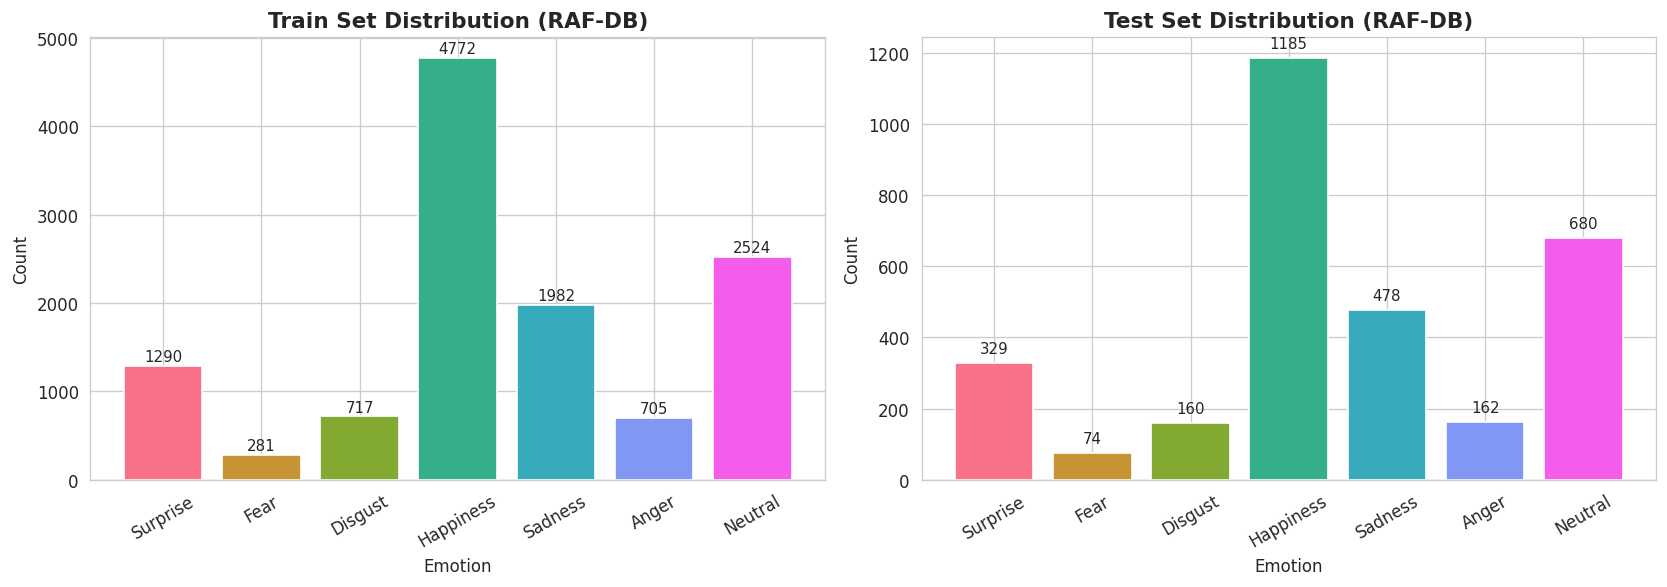

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
palette = sns.color_palette("husl", NUM_CLASSES)

for ax, split, counts in zip(axes, ["Train", "Test"], [train_counts, test_counts]):
    bars = ax.bar(counts.keys(), counts.values(), color=palette)
    ax.set_title(f"{split} Set Distribution (RAF-DB)", fontsize=13, fontweight="bold")
    ax.set_xlabel("Emotion"); ax.set_ylabel("Count")
    ax.tick_params(axis="x", rotation=30)
    for bar, val in zip(bars, counts.values()):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 20,
                str(val), ha="center", va="bottom", fontsize=9)
plt.tight_layout(); plt.show()

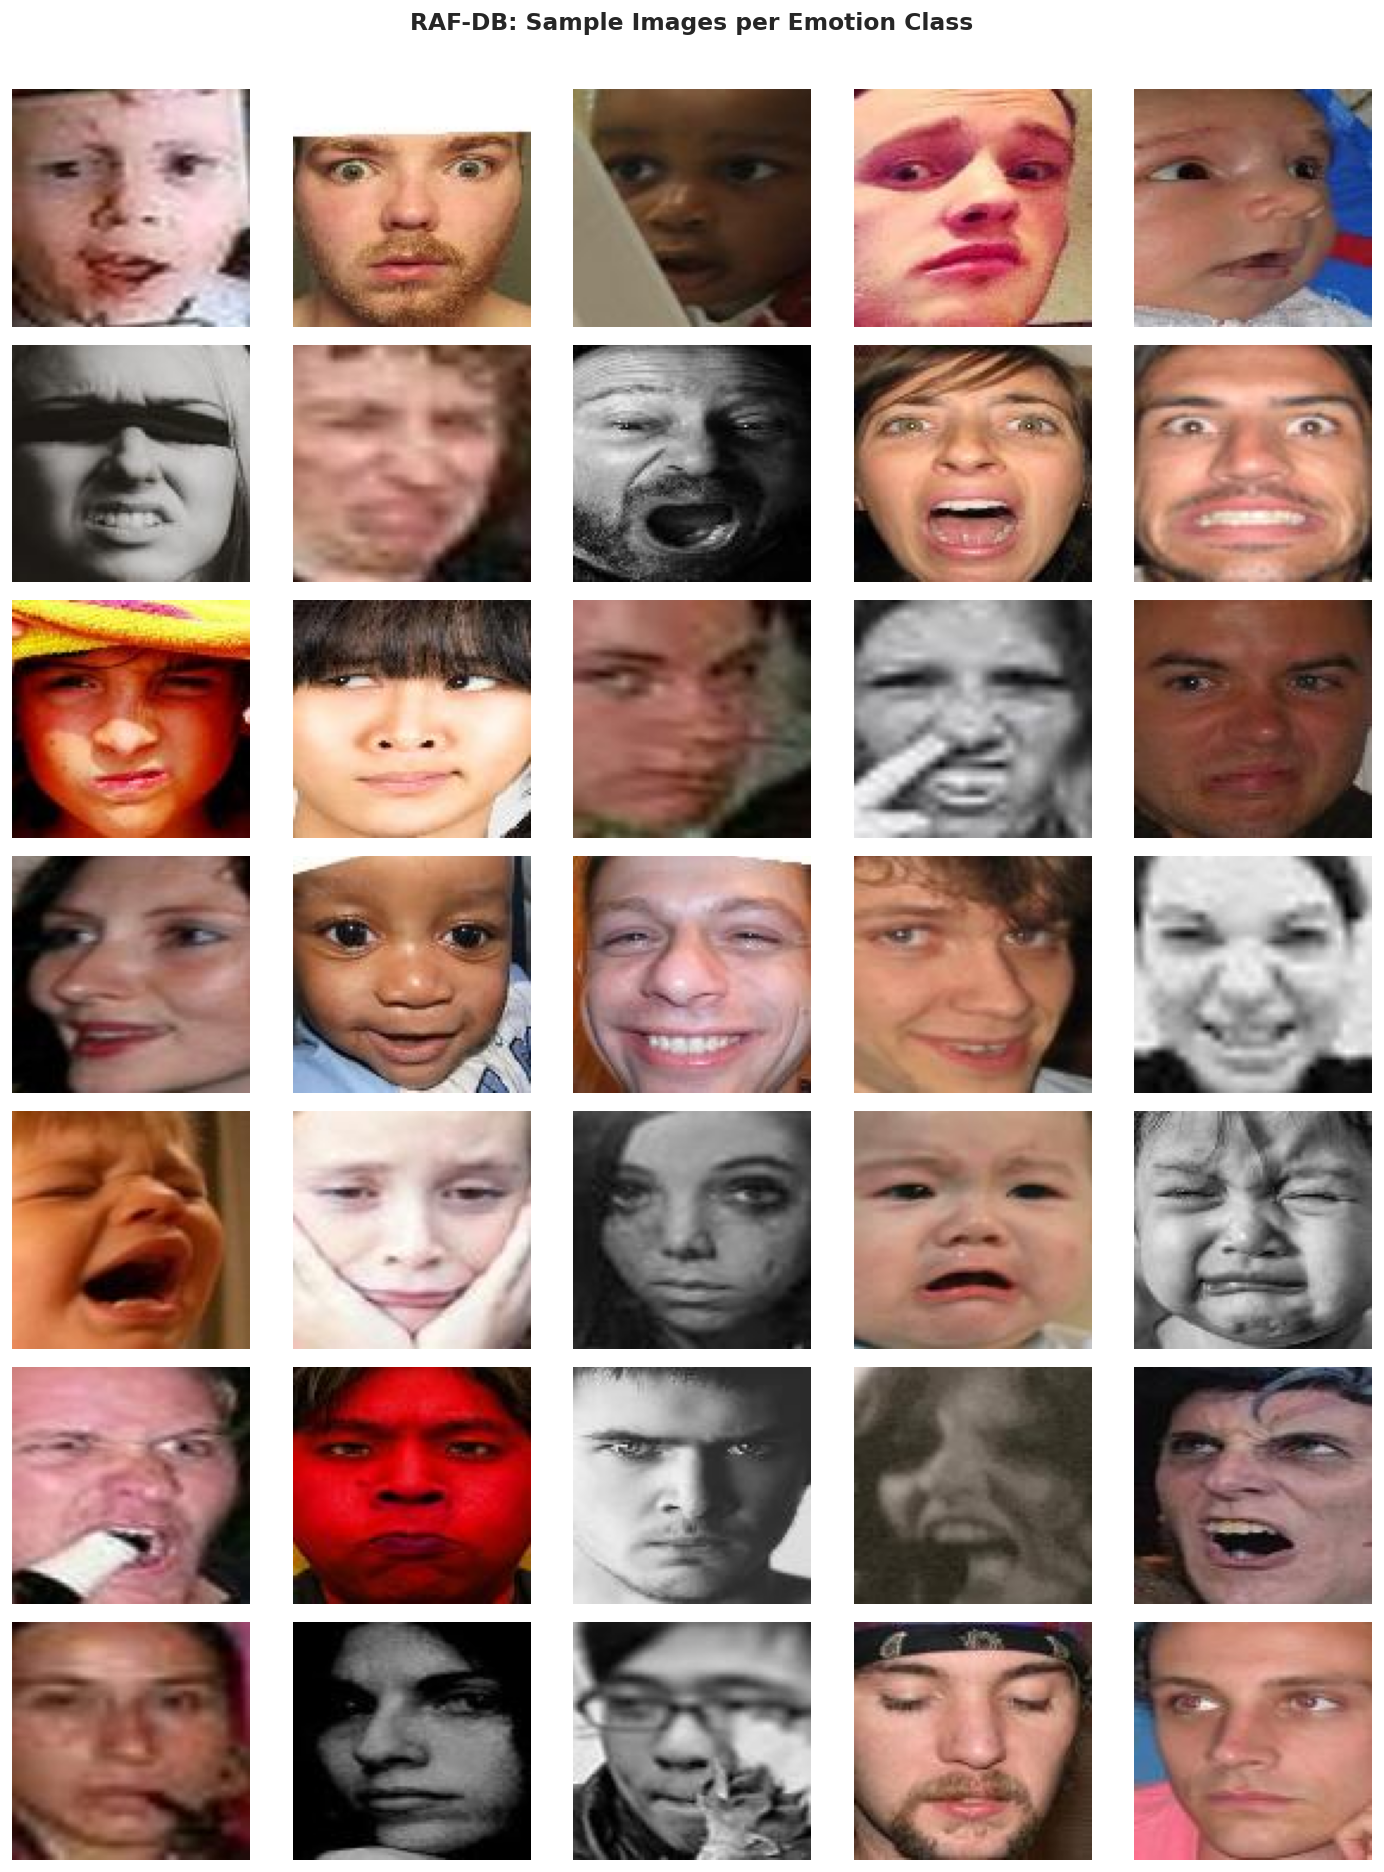

In [6]:
# Sample images per class (5 per emotion)
fig, axes = plt.subplots(NUM_CLASSES, 5, figsize=(12, NUM_CLASSES * 2.2))
for i, (folder_id, emotion) in enumerate(LABEL_MAP.items()):
    imgs = list((TRAIN_DIR / folder_id).glob("*.jpg"))[:5]
    for j, p in enumerate(imgs):
        img = Image.open(p).convert("RGB")
        axes[i, j].imshow(img)
        axes[i, j].axis("off")
        if j == 0:
            axes[i, j].set_ylabel(emotion, fontsize=10, fontweight="bold",
                                  rotation=0, labelpad=65, va="center")
plt.suptitle("RAF-DB: Sample Images per Emotion Class", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout(); plt.show()

In [7]:
# Check image sizes (RAF-DB images are pre-aligned at 100×100)
sizes = []
for folder_id in LABEL_MAP:
    for p in list((TRAIN_DIR / folder_id).glob("*.jpg"))[:20]:
        try:
            w, h = Image.open(p).size
            sizes.append((w, h))
        except: pass

ws, hs = zip(*sizes)
print(f"Width  — min:{min(ws)} max:{max(ws)} mean:{np.mean(ws):.0f}")
print(f"Height — min:{min(hs)} max:{max(hs)} mean:{np.mean(hs):.0f}")
print("RAF-DB images are pre-aligned at 100×100 pixels (aligned variant).")
print("We resize to 48×48 for lightweight models and 224×224 for transfer learning.")

Width  — min:100 max:100 mean:100
Height — min:100 max:100 mean:100
RAF-DB images are pre-aligned at 100×100 pixels (aligned variant).
We resize to 48×48 for lightweight models and 224×224 for transfer learning.


## 🔧 4. Data Preprocessing & Augmentation

RAF-DB images are **RGB colour** (unlike grayscale FER+). For small models we convert to grayscale to reduce parameter count; pretrained models use 3-channel RGB with ImageNet normalisation.

In [8]:
IMG_SIZE   = 48    # for lightweight models
BATCH_SIZE = 128 if torch.cuda.is_available() else 64
LARGE_BATCH = 64  if torch.cuda.is_available() else 32

# ── Small-model transforms (48×48 grayscale) ──
small_train_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.3, contrast=0.3),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])
small_val_tf = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5], [0.5])
])

# ── Large-model transforms (224×224 RGB — ImageNet normalisation) ──
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

large_train_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    transforms.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])
large_val_tf = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD)
])

# ── ImageFolder datasets ──
# ImageFolder sorts subfolders alphabetically: "1","2",...,"7"
# which maps to indices 0–6 → Surprise, Fear, Disgust, Happiness, Sadness, Anger, Neutral
small_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=small_train_tf)
small_test_ds  = datasets.ImageFolder(TEST_DIR,  transform=small_val_tf)
large_train_ds = datasets.ImageFolder(TRAIN_DIR, transform=large_train_tf)
large_test_ds  = datasets.ImageFolder(TEST_DIR,  transform=large_val_tf)

# Override class names from "1".."7" to emotion strings
for ds in [small_train_ds, small_test_ds, large_train_ds, large_test_ds]:
    ds.classes = CLASSES
    ds.class_to_idx = CLASS2IDX

print("ImageFolder class order:", small_train_ds.classes)
print(f"Train samples: {len(small_train_ds)} | Test samples: {len(small_test_ds)}")

# ── WeightedRandomSampler to handle class imbalance ──
# RAF-DB is heavily imbalanced (Happiness: 4772 vs Fear: 281)
def make_sampler(dataset):
    labels = [s[1] for s in dataset.samples]
    counts = Counter(labels)
    weights = [1.0 / counts[l] for l in labels]
    return WeightedRandomSampler(weights, len(weights))

PIN = torch.cuda.is_available()
N_WORKERS = 4 if torch.cuda.is_available() else 2

small_train_loader = DataLoader(small_train_ds, batch_size=BATCH_SIZE,
                                sampler=make_sampler(small_train_ds),
                                num_workers=N_WORKERS, pin_memory=PIN,
                                persistent_workers=True)
small_test_loader  = DataLoader(small_test_ds,  batch_size=BATCH_SIZE,
                                shuffle=False, num_workers=N_WORKERS,
                                pin_memory=PIN, persistent_workers=True)

large_train_loader = DataLoader(large_train_ds, batch_size=LARGE_BATCH,
                                sampler=make_sampler(large_train_ds),
                                num_workers=N_WORKERS, pin_memory=PIN,
                                persistent_workers=True)
large_test_loader  = DataLoader(large_test_ds,  batch_size=LARGE_BATCH,
                                shuffle=False, num_workers=N_WORKERS,
                                pin_memory=PIN, persistent_workers=True)

print("Small train batches:", len(small_train_loader))
print("Large train batches:", len(large_train_loader))

ImageFolder class order: ['Surprise', 'Fear', 'Disgust', 'Happiness', 'Sadness', 'Anger', 'Neutral']
Train samples: 12271 | Test samples: 3068
Small train batches: 96
Large train batches: 192


## 🧰 5. Helper Functions

In [9]:
def train_epoch(model, loader, criterion, optimizer, scaler=None):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        if scaler:  # AMP
            with torch.amp.autocast(device_type=DEVICE.type):
                out  = model(X)
                loss = criterion(out, y)
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
        else:
            out  = model(X)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
        total_loss += loss.item() * X.size(0)
        correct    += (out.argmax(1) == y).sum().item()
        total      += X.size(0)
    return total_loss / total, correct / total


@torch.no_grad()
def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    all_preds, all_labels = [], []
    for X, y in loader:
        X, y = X.to(DEVICE), y.to(DEVICE)
        out  = model(X)
        loss = criterion(out, y)
        total_loss += loss.item() * X.size(0)
        preds = out.argmax(1)
        correct += (preds == y).sum().item()
        total   += X.size(0)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.cpu().numpy())
    return total_loss / total, correct / total, all_preds, all_labels


def fit(model, train_loader, test_loader, epochs=20, lr=1e-3, weight_decay=1e-4,
        scheduler_type="cosine", label_smooth=0.1, use_amp=True):
    criterion = nn.CrossEntropyLoss(label_smoothing=label_smooth)
    optimizer = optim.AdamW(model.parameters(), lr=lr, weight_decay=weight_decay)
    if scheduler_type == "cosine":
        scheduler = optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
    else:
        scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, patience=3, factor=0.5)

    scaler = torch.cuda.amp.GradScaler() if (use_amp and DEVICE.type == "cuda") else None
    history = {"train_loss":[], "train_acc":[], "val_loss":[], "val_acc":[]}
    best_acc, best_state = 0, None

    for ep in range(1, epochs+1):
        t0 = time.time()
        tl, ta = train_epoch(model, train_loader, criterion, optimizer, scaler)
        vl, va, _, _ = eval_epoch(model, test_loader, criterion)
        if isinstance(scheduler, optim.lr_scheduler.ReduceLROnPlateau):
            scheduler.step(vl)
        else:
            scheduler.step()
        history["train_loss"].append(tl); history["train_acc"].append(ta)
        history["val_loss"].append(vl);   history["val_acc"].append(va)
        if va > best_acc:
            best_acc = va
            best_state = {k: v.cpu().clone() for k, v in model.state_dict().items()}
        print(f"Ep {ep:03d}/{epochs} | "
              f"Train {ta:.3f} | Val {va:.3f} | "
              f"LR {scheduler.get_last_lr()[0]:.2e} | {time.time()-t0:.1f}s")
    model.load_state_dict(best_state)
    return history, best_acc


def plot_history(history, title):
    fig, (a1, a2) = plt.subplots(1, 2, figsize=(13, 4))
    epochs = range(1, len(history["train_loss"])+1)
    a1.plot(epochs, history["train_loss"], label="Train")
    a1.plot(epochs, history["val_loss"],   label="Val")
    a1.set_title(f"{title} — Loss"); a1.legend()
    a2.plot(epochs, history["train_acc"], label="Train")
    a2.plot(epochs, history["val_acc"],   label="Val")
    a2.set_title(f"{title} — Accuracy"); a2.legend()
    plt.tight_layout(); plt.show()


def show_confusion(model, loader, title):
    criterion = nn.CrossEntropyLoss()
    _, acc, preds, labels = eval_epoch(model, loader, criterion)
    cm = confusion_matrix(labels, preds)
    fig, ax = plt.subplots(figsize=(8, 7))
    disp = ConfusionMatrixDisplay(cm, display_labels=CLASSES)
    disp.plot(ax=ax, cmap="Blues", xticks_rotation=45)
    ax.set_title(f"{title} — Acc: {acc:.3f}", fontsize=12, fontweight="bold")
    plt.tight_layout(); plt.show()
    print(classification_report(labels, preds, target_names=CLASSES))
    return acc, preds, labels


results = {}  # {model_name: best_val_acc}

---
# 🟢 NORMAL MODELS
---

## Model 1 — HOG + SVM (Classical ML)

HOG features extracted from grayscale 48×48 crops, reduced via PCA, classified by an RBF-kernel SVM.

In [10]:
def extract_hog_features(root, size=(48, 48), limit=None):
    """Extract HOG features from numbered RAF-DB subfolders."""
    X, y = [], []
    for folder_id, emotion in LABEL_MAP.items():
        paths = list((root / folder_id).glob("*.jpg"))
        if limit: paths = paths[:limit]
        idx = CLASS2IDX[emotion]
        for p in paths:
            img = cv2.imread(str(p), cv2.IMREAD_GRAYSCALE)
            if img is None: continue
            img = cv2.resize(img, size)
            feat = hog(img, orientations=9, pixels_per_cell=(8, 8),
                       cells_per_block=(2, 2), block_norm="L2-Hys")
            X.append(feat); y.append(idx)
    return np.array(X), np.array(y)

print("Extracting HOG features...")
X_train_hog, y_train_hog = extract_hog_features(TRAIN_DIR)
X_test_hog,  y_test_hog  = extract_hog_features(TEST_DIR)
print(f"Train: {X_train_hog.shape} | Test: {X_test_hog.shape}")

Extracting HOG features...
Train: (12271, 900) | Test: (3068, 900)


Training HOG + SVM...
HOG + SVM Accuracy: 0.7066
              precision    recall  f1-score   support

    Surprise       0.66      0.59      0.62       329
        Fear       0.92      0.32      0.48        74
     Disgust       0.45      0.23      0.30       160
   Happiness       0.81      0.89      0.85      1185
     Sadness       0.58      0.58      0.58       478
       Anger       0.61      0.55      0.58       162
     Neutral       0.66      0.72      0.69       680

    accuracy                           0.71      3068
   macro avg       0.67      0.56      0.59      3068
weighted avg       0.70      0.71      0.70      3068



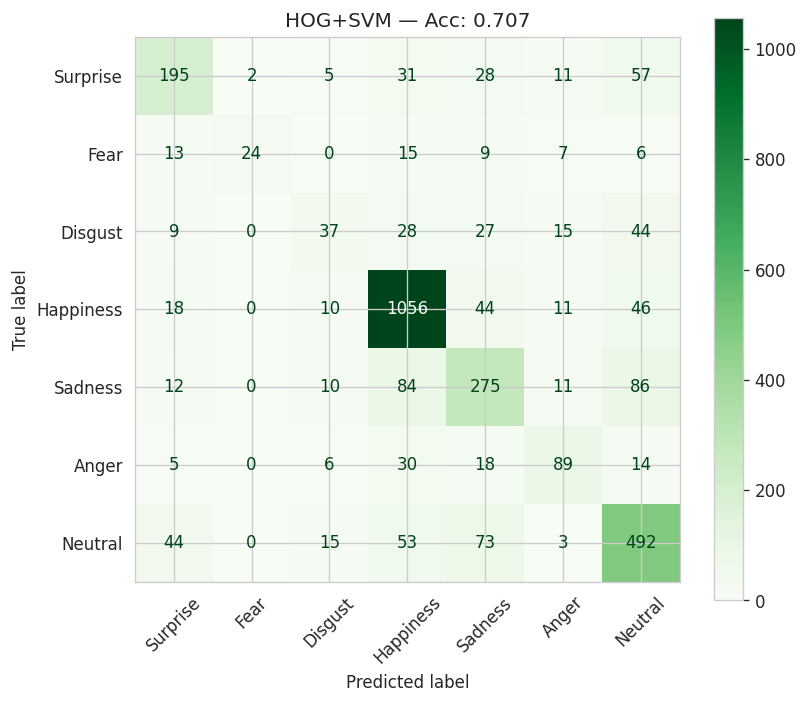

In [11]:
n_pca = min(200, X_train_hog.shape[0], X_train_hog.shape[1])
svm_pipe = Pipeline([
    ("pca", PCA(n_components=n_pca, random_state=SEED)),
    ("svm", SVC(kernel="rbf", C=10, gamma="scale", probability=True, random_state=SEED))
])
print("Training HOG + SVM...")
svm_pipe.fit(X_train_hog, y_train_hog)
svm_preds = svm_pipe.predict(X_test_hog)
svm_acc   = accuracy_score(y_test_hog, svm_preds)
print(f"HOG + SVM Accuracy: {svm_acc:.4f}")
print(classification_report(y_test_hog, svm_preds, target_names=CLASSES))
results["HOG+SVM"] = svm_acc

cm = confusion_matrix(y_test_hog, svm_preds)
fig, ax = plt.subplots(figsize=(7, 6))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Greens", xticks_rotation=45)
ax.set_title(f"HOG+SVM — Acc: {svm_acc:.3f}")
plt.tight_layout(); plt.show()

## Model 2 — Simple Custom CNN

In [12]:
class SimpleCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 2
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
            # Block 3
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Conv2d(128, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.MaxPool2d(2), nn.Dropout2d(0.25),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 6 * 6, 512), nn.ReLU(), nn.Dropout(0.5),
            nn.Linear(512, 256), nn.ReLU(), nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.classifier(self.features(x))


cnn = SimpleCNN(NUM_CLASSES).to(DEVICE)
summary(cnn, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
SimpleCNN                                [1, 7]                    --
├─Sequential: 1-1                        [1, 128, 6, 6]            --
│    └─Conv2d: 2-1                       [1, 32, 48, 48]           320
│    └─BatchNorm2d: 2-2                  [1, 32, 48, 48]           64
│    └─ReLU: 2-3                         [1, 32, 48, 48]           --
│    └─Conv2d: 2-4                       [1, 32, 48, 48]           9,248
│    └─BatchNorm2d: 2-5                  [1, 32, 48, 48]           64
│    └─ReLU: 2-6                         [1, 32, 48, 48]           --
│    └─MaxPool2d: 2-7                    [1, 32, 24, 24]           --
│    └─Dropout2d: 2-8                    [1, 32, 24, 24]           --
│    └─Conv2d: 2-9                       [1, 64, 24, 24]           18,496
│    └─BatchNorm2d: 2-10                 [1, 64, 24, 24]           128
│    └─ReLU: 2-11                        [1, 64, 24, 24]           --
│    └

In [13]:
cnn_hist, cnn_acc = fit(cnn, small_train_loader, small_test_loader,
                        epochs=30, lr=1e-3)
results["SimpleCNN"] = cnn_acc

Ep 001/30 | Train 0.179 | Val 0.279 | LR 9.97e-04 | 52.0s
Ep 002/30 | Train 0.224 | Val 0.301 | LR 9.89e-04 | 38.4s
Ep 003/30 | Train 0.263 | Val 0.317 | LR 9.76e-04 | 15.1s
Ep 004/30 | Train 0.283 | Val 0.361 | LR 9.57e-04 | 15.4s
Ep 005/30 | Train 0.337 | Val 0.369 | LR 9.33e-04 | 11.0s
Ep 006/30 | Train 0.403 | Val 0.555 | LR 9.05e-04 | 16.7s
Ep 007/30 | Train 0.449 | Val 0.568 | LR 8.72e-04 | 23.4s
Ep 008/30 | Train 0.475 | Val 0.613 | LR 8.35e-04 | 16.0s
Ep 009/30 | Train 0.519 | Val 0.619 | LR 7.94e-04 | 9.5s
Ep 010/30 | Train 0.530 | Val 0.639 | LR 7.50e-04 | 9.0s
Ep 011/30 | Train 0.546 | Val 0.641 | LR 7.03e-04 | 10.4s
Ep 012/30 | Train 0.555 | Val 0.647 | LR 6.55e-04 | 9.3s
Ep 013/30 | Train 0.569 | Val 0.647 | LR 6.04e-04 | 9.2s
Ep 014/30 | Train 0.582 | Val 0.652 | LR 5.52e-04 | 9.1s
Ep 015/30 | Train 0.591 | Val 0.669 | LR 5.00e-04 | 8.9s
Ep 016/30 | Train 0.605 | Val 0.686 | LR 4.48e-04 | 8.7s
Ep 017/30 | Train 0.614 | Val 0.656 | LR 3.96e-04 | 9.0s
Ep 018/30 | Train 0.62

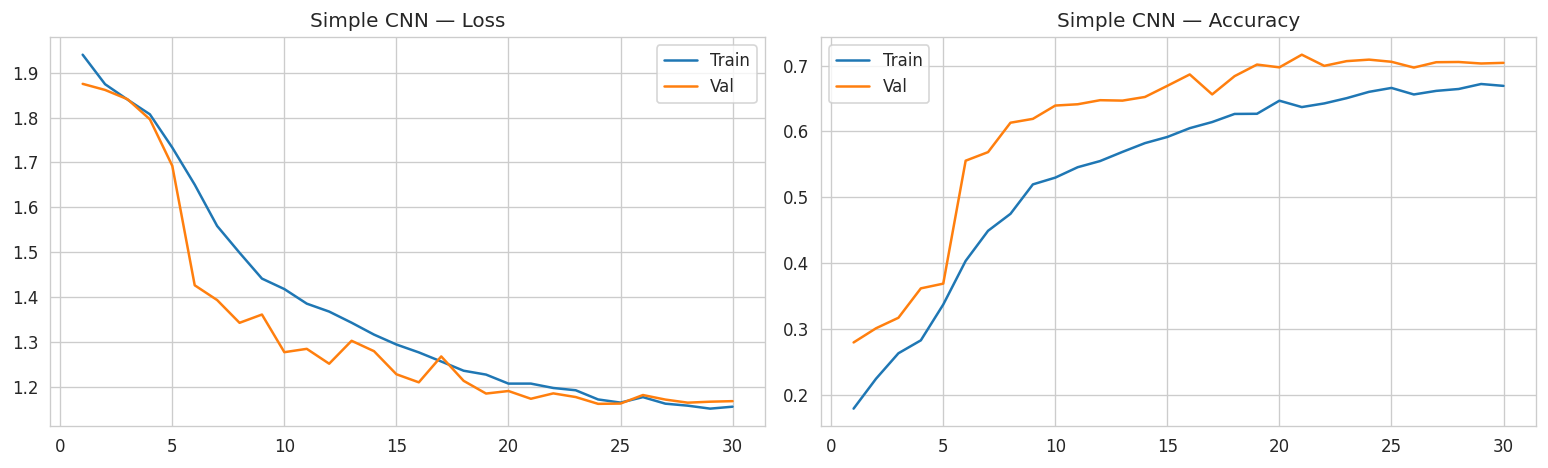

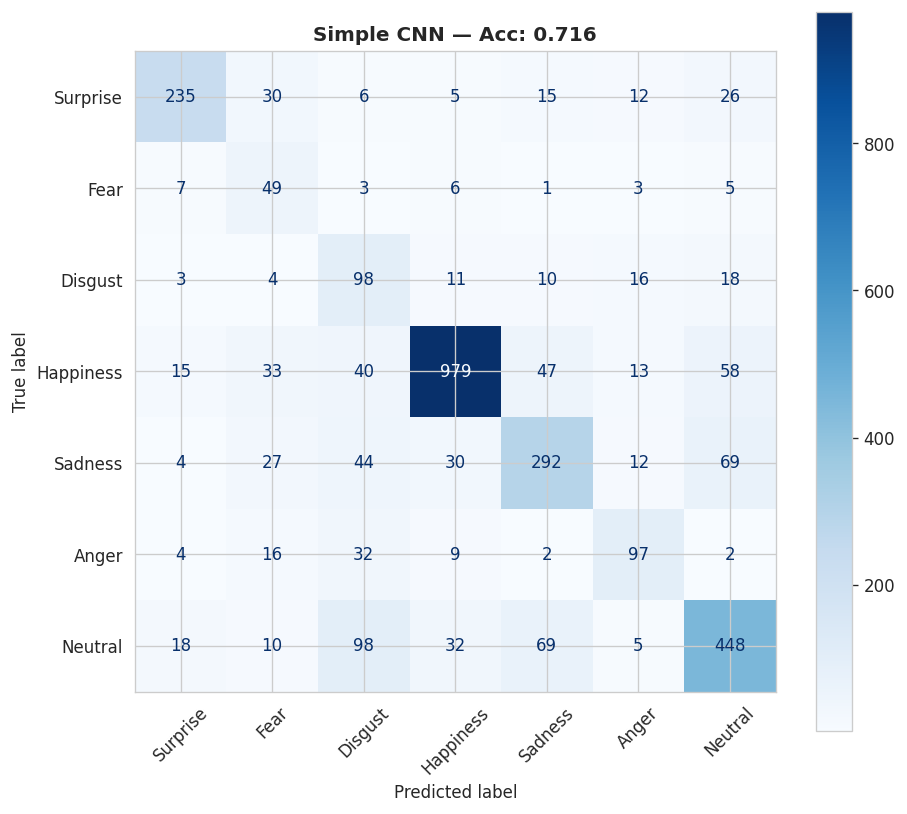

              precision    recall  f1-score   support

    Surprise       0.82      0.71      0.76       329
        Fear       0.29      0.66      0.40        74
     Disgust       0.31      0.61      0.41       160
   Happiness       0.91      0.83      0.87      1185
     Sadness       0.67      0.61      0.64       478
       Anger       0.61      0.60      0.61       162
     Neutral       0.72      0.66      0.69       680

    accuracy                           0.72      3068
   macro avg       0.62      0.67      0.62      3068
weighted avg       0.76      0.72      0.73      3068



In [14]:
plot_history(cnn_hist, "Simple CNN")
show_confusion(cnn, small_test_loader, "Simple CNN");

## Model 3 — Deeper CNN with Residual Blocks (custom)

In [15]:
class ResBlock(nn.Module):
    def __init__(self, ch):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch), nn.ReLU(),
            nn.Conv2d(ch, ch, 3, padding=1, bias=False),
            nn.BatchNorm2d(ch)
        )
    def forward(self, x):
        return F.relu(self.net(x) + x)


class DeepCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        self.stem = nn.Sequential(
            nn.Conv2d(1, 64, 3, padding=1, bias=False),
            nn.BatchNorm2d(64), nn.ReLU(),
            nn.MaxPool2d(2)           # 48→24
        )
        self.layer1 = nn.Sequential(ResBlock(64), ResBlock(64),
                                    nn.MaxPool2d(2), nn.Dropout2d(0.2))  # 24→12
        self.layer2 = nn.Sequential(
            nn.Conv2d(64, 128, 1, bias=False), nn.BatchNorm2d(128),
            ResBlock(128), ResBlock(128),
            nn.MaxPool2d(2), nn.Dropout2d(0.2))   # 12→6
        self.head = nn.Sequential(
            nn.AdaptiveAvgPool2d(1), nn.Flatten(),
            nn.Linear(128, 256), nn.ReLU(), nn.Dropout(0.4),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        return self.head(self.layer2(self.layer1(self.stem(x))))


deep_cnn = DeepCNN(NUM_CLASSES).to(DEVICE)
summary(deep_cnn, input_size=(1, 1, 48, 48))

Layer (type:depth-idx)                   Output Shape              Param #
DeepCNN                                  [1, 7]                    --
├─Sequential: 1-1                        [1, 64, 24, 24]           --
│    └─Conv2d: 2-1                       [1, 64, 48, 48]           576
│    └─BatchNorm2d: 2-2                  [1, 64, 48, 48]           128
│    └─ReLU: 2-3                         [1, 64, 48, 48]           --
│    └─MaxPool2d: 2-4                    [1, 64, 24, 24]           --
├─Sequential: 1-2                        [1, 64, 12, 12]           --
│    └─ResBlock: 2-5                     [1, 64, 24, 24]           --
│    │    └─Sequential: 3-1              [1, 64, 24, 24]           73,984
│    └─ResBlock: 2-6                     [1, 64, 24, 24]           --
│    │    └─Sequential: 3-2              [1, 64, 24, 24]           73,984
│    └─MaxPool2d: 2-7                    [1, 64, 12, 12]           --
│    └─Dropout2d: 2-8                    [1, 64, 12, 12]           --
├─Seq

In [16]:
deep_hist, deep_acc = fit(deep_cnn, small_train_loader, small_test_loader,
                          epochs=35, lr=1e-3, weight_decay=1e-4)
results["DeepCNN"] = deep_acc

Ep 001/35 | Train 0.193 | Val 0.221 | LR 9.98e-04 | 13.4s
Ep 002/35 | Train 0.227 | Val 0.216 | LR 9.92e-04 | 10.0s
Ep 003/35 | Train 0.236 | Val 0.401 | LR 9.82e-04 | 8.4s
Ep 004/35 | Train 0.271 | Val 0.415 | LR 9.68e-04 | 8.8s
Ep 005/35 | Train 0.314 | Val 0.426 | LR 9.50e-04 | 8.4s
Ep 006/35 | Train 0.382 | Val 0.417 | LR 9.29e-04 | 9.6s
Ep 007/35 | Train 0.439 | Val 0.358 | LR 9.05e-04 | 9.6s
Ep 008/35 | Train 0.481 | Val 0.537 | LR 8.77e-04 | 9.7s
Ep 009/35 | Train 0.519 | Val 0.497 | LR 8.46e-04 | 9.2s
Ep 010/35 | Train 0.544 | Val 0.603 | LR 8.12e-04 | 9.5s
Ep 011/35 | Train 0.567 | Val 0.514 | LR 7.75e-04 | 9.5s
Ep 012/35 | Train 0.585 | Val 0.623 | LR 7.37e-04 | 13.0s
Ep 013/35 | Train 0.599 | Val 0.583 | LR 6.97e-04 | 19.3s
Ep 014/35 | Train 0.614 | Val 0.684 | LR 6.55e-04 | 10.0s
Ep 015/35 | Train 0.617 | Val 0.645 | LR 6.11e-04 | 14.8s
Ep 016/35 | Train 0.636 | Val 0.643 | LR 5.67e-04 | 15.3s
Ep 017/35 | Train 0.646 | Val 0.701 | LR 5.22e-04 | 12.7s
Ep 018/35 | Train 0.661

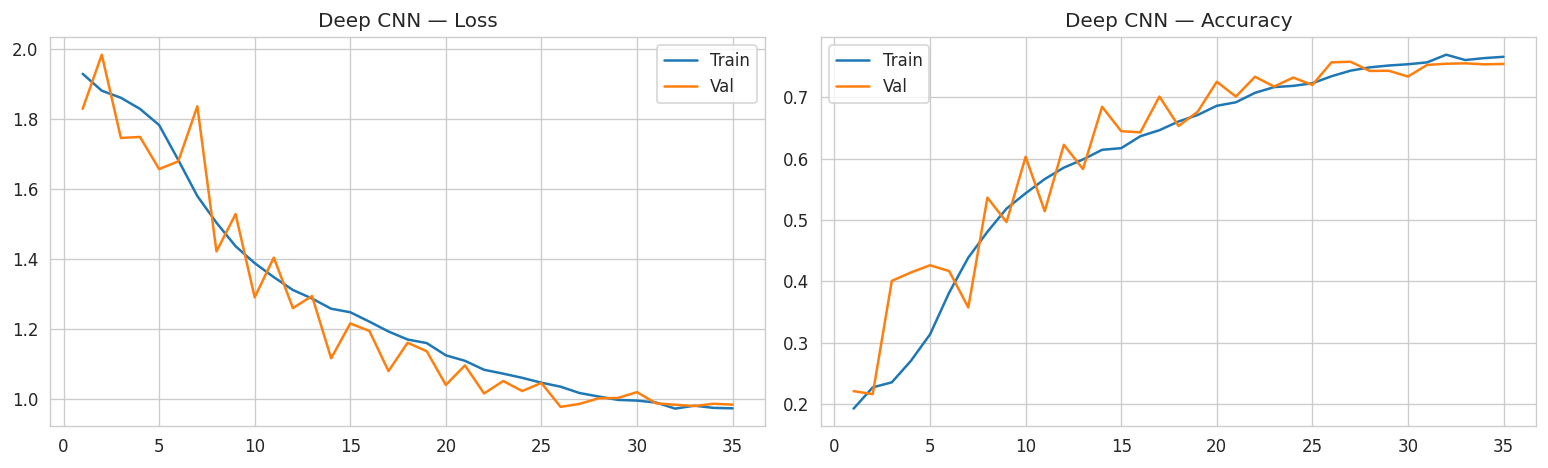

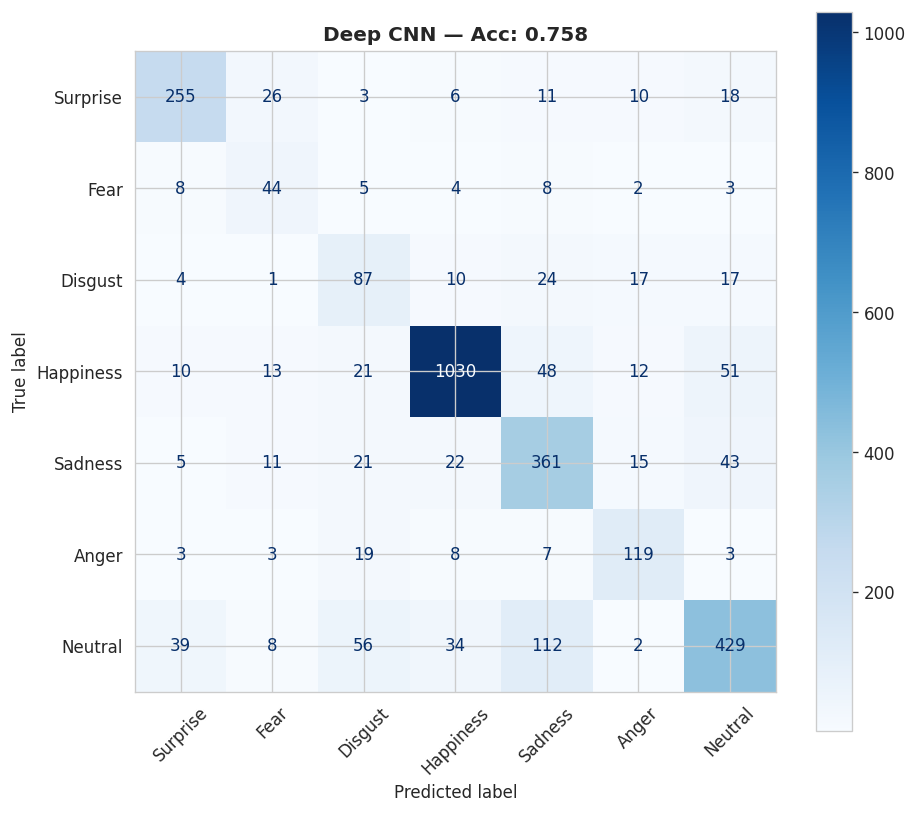

              precision    recall  f1-score   support

    Surprise       0.79      0.78      0.78       329
        Fear       0.42      0.59      0.49        74
     Disgust       0.41      0.54      0.47       160
   Happiness       0.92      0.87      0.90      1185
     Sadness       0.63      0.76      0.69       478
       Anger       0.67      0.73      0.70       162
     Neutral       0.76      0.63      0.69       680

    accuracy                           0.76      3068
   macro avg       0.66      0.70      0.67      3068
weighted avg       0.78      0.76      0.76      3068



In [17]:
plot_history(deep_hist, "Deep CNN")
show_confusion(deep_cnn, small_test_loader, "Deep CNN");

---
# 🔵 ADVANCED MODELS
---

## Model 4 — ResNet50 (Transfer Learning)

In [18]:
def build_resnet50(num_classes, freeze_until=6):
    model = models.resnet50(weights=models.ResNet50_Weights.DEFAULT)
    children = list(model.children())
    for layer in children[:freeze_until]:
        for p in layer.parameters():
            p.requires_grad = False
    in_feat = model.fc.in_features
    model.fc = nn.Sequential(
        nn.Linear(in_feat, 512), nn.ReLU(), nn.Dropout(0.4),
        nn.Linear(512, num_classes)
    )
    return model


resnet = build_resnet50(NUM_CLASSES).to(DEVICE)
print("ResNet50 ready. Trainable params:",
      sum(p.numel() for p in resnet.parameters() if p.requires_grad))

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 181MB/s]


ResNet50 ready. Trainable params: 23115783


In [19]:
# Phase 1 — warm-up: train head only
resnet_hist1, _ = fit(resnet, large_train_loader, large_test_loader,
                      epochs=5, lr=1e-3, label_smooth=0.1)

# Phase 2 — unfreeze all & fine-tune
for p in resnet.parameters():
    p.requires_grad = True

resnet_hist2, resnet_acc = fit(resnet, large_train_loader, large_test_loader,
                               epochs=20, lr=3e-5, weight_decay=1e-5,
                               scheduler_type="cosine", label_smooth=0.1)
results["ResNet50"] = resnet_acc
print(f"ResNet50 Best Val Acc: {resnet_acc:.4f}")

Ep 001/5 | Train 0.542 | Val 0.535 | LR 9.05e-04 | 60.8s
Ep 002/5 | Train 0.722 | Val 0.765 | LR 6.55e-04 | 42.7s
Ep 003/5 | Train 0.806 | Val 0.779 | LR 3.45e-04 | 41.9s
Ep 004/5 | Train 0.865 | Val 0.765 | LR 9.55e-05 | 41.7s
Ep 005/5 | Train 0.900 | Val 0.805 | LR 0.00e+00 | 44.3s
Ep 001/20 | Train 0.915 | Val 0.824 | LR 2.98e-05 | 67.6s
Ep 002/20 | Train 0.926 | Val 0.820 | LR 2.93e-05 | 58.9s
Ep 003/20 | Train 0.931 | Val 0.829 | LR 2.84e-05 | 59.4s
Ep 004/20 | Train 0.936 | Val 0.835 | LR 2.71e-05 | 59.2s
Ep 005/20 | Train 0.941 | Val 0.830 | LR 2.56e-05 | 58.8s
Ep 006/20 | Train 0.944 | Val 0.831 | LR 2.38e-05 | 58.9s
Ep 007/20 | Train 0.949 | Val 0.836 | LR 2.18e-05 | 59.2s
Ep 008/20 | Train 0.949 | Val 0.835 | LR 1.96e-05 | 59.9s
Ep 009/20 | Train 0.957 | Val 0.838 | LR 1.73e-05 | 59.0s
Ep 010/20 | Train 0.959 | Val 0.839 | LR 1.50e-05 | 59.0s
Ep 011/20 | Train 0.960 | Val 0.841 | LR 1.27e-05 | 58.9s
Ep 012/20 | Train 0.961 | Val 0.840 | LR 1.04e-05 | 58.9s
Ep 013/20 | Train 0

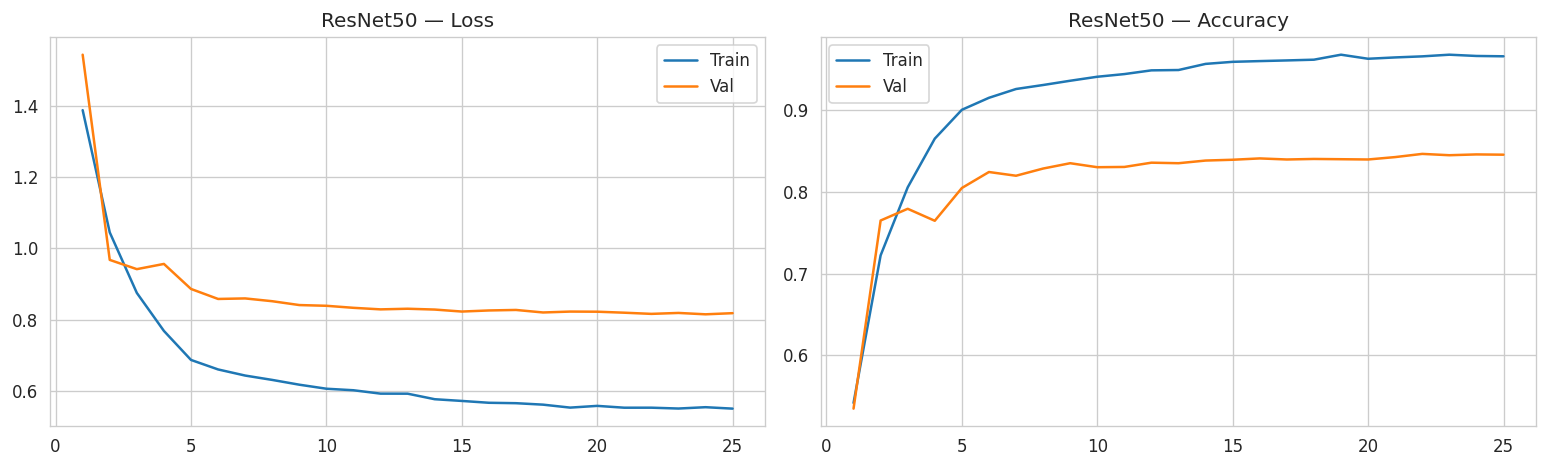

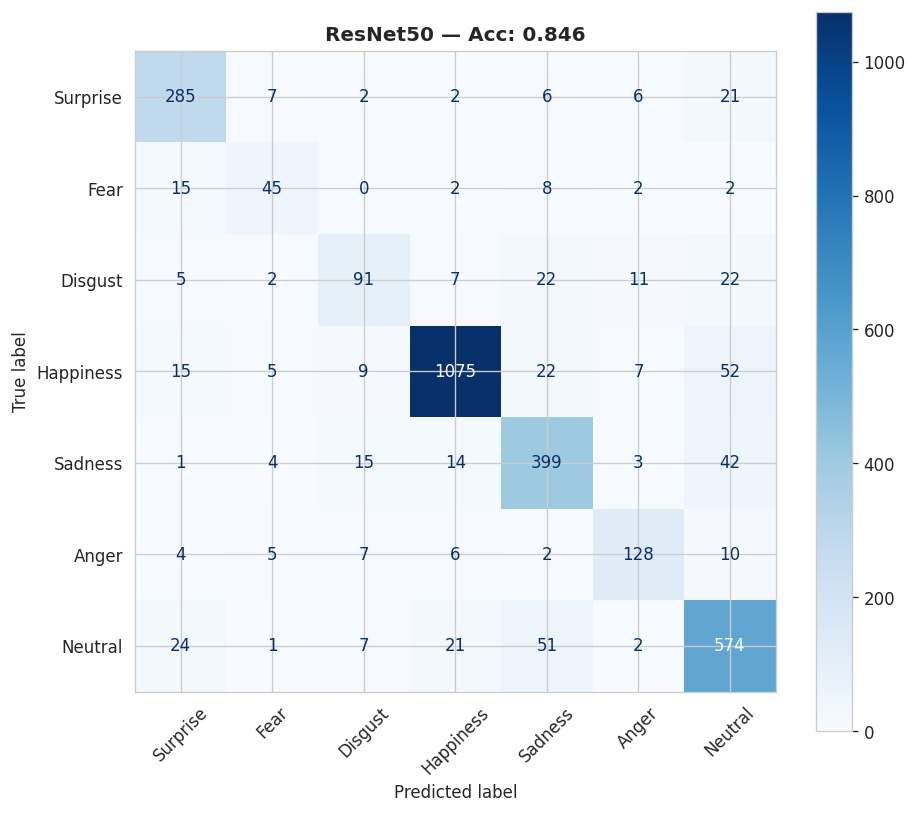

              precision    recall  f1-score   support

    Surprise       0.82      0.87      0.84       329
        Fear       0.65      0.61      0.63        74
     Disgust       0.69      0.57      0.63       160
   Happiness       0.95      0.91      0.93      1185
     Sadness       0.78      0.83      0.81       478
       Anger       0.81      0.79      0.80       162
     Neutral       0.79      0.84      0.82       680

    accuracy                           0.85      3068
   macro avg       0.79      0.77      0.78      3068
weighted avg       0.85      0.85      0.85      3068



In [20]:
def merge_hist(h1, h2):
    return {k: h1[k] + h2[k] for k in h1}

plot_history(merge_hist(resnet_hist1, resnet_hist2), "ResNet50")
show_confusion(resnet, large_test_loader, "ResNet50");

## Model 5 — EfficientNetB3 (Transfer Learning)

In [21]:
def build_efficientnet(num_classes, variant="efficientnet_b3"):
    model = timm.create_model(variant, pretrained=True, num_classes=0)
    in_feat = model.num_features
    blocks = list(model.named_children())
    for name, child in blocks[:-2]:
        for p in child.parameters():
            p.requires_grad = False
    full_model = nn.Sequential(
        model,
        nn.Dropout(0.4),
        nn.Linear(in_feat, 512), nn.GELU(), nn.Dropout(0.3),
        nn.Linear(512, num_classes)
    )
    return full_model


effnet = build_efficientnet(NUM_CLASSES, "efficientnet_b3").to(DEVICE)
print("EfficientNetB3 ready. Trainable params:",
      sum(p.numel() for p in effnet.parameters() if p.requires_grad))

model.safetensors:   0%|          | 0.00/49.3M [00:00<?, ?B/s]

EfficientNetB3 ready. Trainable params: 790535


In [22]:
# Phase 1
eff_hist1, _ = fit(effnet, large_train_loader, large_test_loader,
                   epochs=5, lr=1e-3)

# Phase 2 — unfreeze & fine-tune
for p in effnet.parameters():
    p.requires_grad = True

eff_hist2, eff_acc = fit(effnet, large_train_loader, large_test_loader,
                         epochs=20, lr=2e-5, weight_decay=1e-5)
results["EfficientNetB3"] = eff_acc
print(f"EfficientNetB3 Best Val Acc: {eff_acc:.4f}")

Ep 001/5 | Train 0.358 | Val 0.372 | LR 9.05e-04 | 53.9s
Ep 002/5 | Train 0.409 | Val 0.429 | LR 6.55e-04 | 37.7s
Ep 003/5 | Train 0.435 | Val 0.455 | LR 3.45e-04 | 37.7s
Ep 004/5 | Train 0.447 | Val 0.434 | LR 9.55e-05 | 37.4s
Ep 005/5 | Train 0.454 | Val 0.431 | LR 0.00e+00 | 37.6s
Ep 001/20 | Train 0.479 | Val 0.493 | LR 1.99e-05 | 160.5s
Ep 002/20 | Train 0.531 | Val 0.535 | LR 1.95e-05 | 69.7s
Ep 003/20 | Train 0.579 | Val 0.573 | LR 1.89e-05 | 69.2s
Ep 004/20 | Train 0.618 | Val 0.600 | LR 1.81e-05 | 69.1s
Ep 005/20 | Train 0.651 | Val 0.621 | LR 1.71e-05 | 69.3s
Ep 006/20 | Train 0.684 | Val 0.647 | LR 1.59e-05 | 69.2s
Ep 007/20 | Train 0.701 | Val 0.656 | LR 1.45e-05 | 69.2s
Ep 008/20 | Train 0.726 | Val 0.676 | LR 1.31e-05 | 69.2s
Ep 009/20 | Train 0.745 | Val 0.688 | LR 1.16e-05 | 69.2s
Ep 010/20 | Train 0.767 | Val 0.696 | LR 1.00e-05 | 69.1s
Ep 011/20 | Train 0.776 | Val 0.708 | LR 8.44e-06 | 69.2s
Ep 012/20 | Train 0.786 | Val 0.713 | LR 6.91e-06 | 69.1s
Ep 013/20 | Train 

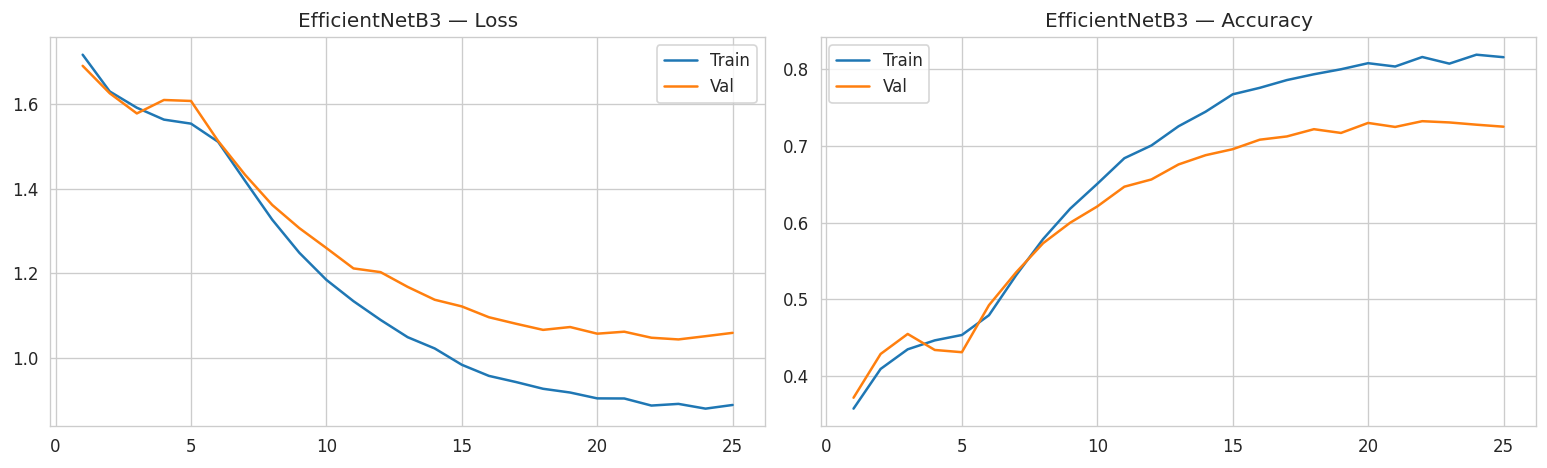

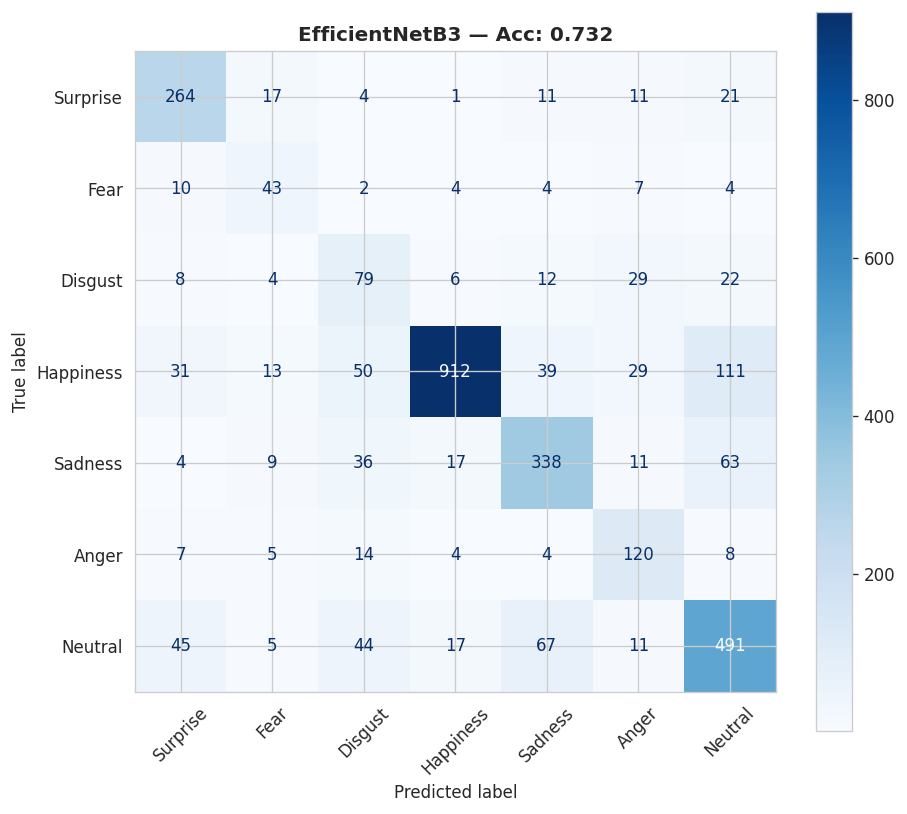

              precision    recall  f1-score   support

    Surprise       0.72      0.80      0.76       329
        Fear       0.45      0.58      0.51        74
     Disgust       0.34      0.49      0.41       160
   Happiness       0.95      0.77      0.85      1185
     Sadness       0.71      0.71      0.71       478
       Anger       0.55      0.74      0.63       162
     Neutral       0.68      0.72      0.70       680

    accuracy                           0.73      3068
   macro avg       0.63      0.69      0.65      3068
weighted avg       0.76      0.73      0.74      3068



In [23]:
plot_history(merge_hist(eff_hist1, eff_hist2), "EfficientNetB3")
show_confusion(effnet, large_test_loader, "EfficientNetB3");

## Model 6 — Vision Transformer (ViT-Small)

In [24]:
def build_vit(num_classes, variant="vit_small_patch16_224"):
    model = timm.create_model(variant, pretrained=True, num_classes=num_classes)
    for name, param in model.named_parameters():
        if any(tag in name for tag in ["patch_embed", "blocks.0", "blocks.1",
                                        "blocks.2", "blocks.3", "blocks.4",
                                        "blocks.5", "pos_embed", "cls_token"]):
            param.requires_grad = False
    return model


vit = build_vit(NUM_CLASSES).to(DEVICE)
print("ViT ready. Trainable params:",
      sum(p.numel() for p in vit.parameters() if p.requires_grad))

model.safetensors:   0%|          | 0.00/88.2M [00:00<?, ?B/s]

ViT ready. Trainable params: 7101319


In [25]:
# Phase 1
vit_hist1, _ = fit(vit, large_train_loader, large_test_loader,
                   epochs=5, lr=5e-4)

# Phase 2
for p in vit.parameters():
    p.requires_grad = True

vit_hist2, vit_acc = fit(vit, large_train_loader, large_test_loader,
                         epochs=20, lr=1e-5, weight_decay=5e-5)
results["ViT-Small"] = vit_acc
print(f"ViT-Small Best Val Acc: {vit_acc:.4f}")

Ep 001/5 | Train 0.517 | Val 0.665 | LR 4.52e-04 | 41.9s
Ep 002/5 | Train 0.745 | Val 0.744 | LR 3.27e-04 | 40.1s
Ep 003/5 | Train 0.825 | Val 0.755 | LR 1.73e-04 | 40.3s
Ep 004/5 | Train 0.885 | Val 0.771 | LR 4.77e-05 | 40.3s
Ep 005/5 | Train 0.918 | Val 0.810 | LR 0.00e+00 | 40.7s
Ep 001/20 | Train 0.935 | Val 0.806 | LR 9.94e-06 | 48.1s
Ep 002/20 | Train 0.942 | Val 0.815 | LR 9.76e-06 | 47.8s
Ep 003/20 | Train 0.949 | Val 0.817 | LR 9.46e-06 | 47.9s
Ep 004/20 | Train 0.956 | Val 0.818 | LR 9.05e-06 | 47.8s
Ep 005/20 | Train 0.959 | Val 0.825 | LR 8.54e-06 | 47.8s
Ep 006/20 | Train 0.964 | Val 0.833 | LR 7.94e-06 | 47.9s
Ep 007/20 | Train 0.967 | Val 0.839 | LR 7.27e-06 | 47.6s
Ep 008/20 | Train 0.970 | Val 0.837 | LR 6.55e-06 | 47.8s
Ep 009/20 | Train 0.971 | Val 0.831 | LR 5.78e-06 | 47.8s
Ep 010/20 | Train 0.973 | Val 0.832 | LR 5.00e-06 | 47.8s
Ep 011/20 | Train 0.975 | Val 0.830 | LR 4.22e-06 | 47.8s
Ep 012/20 | Train 0.978 | Val 0.831 | LR 3.45e-06 | 47.9s
Ep 013/20 | Train 0

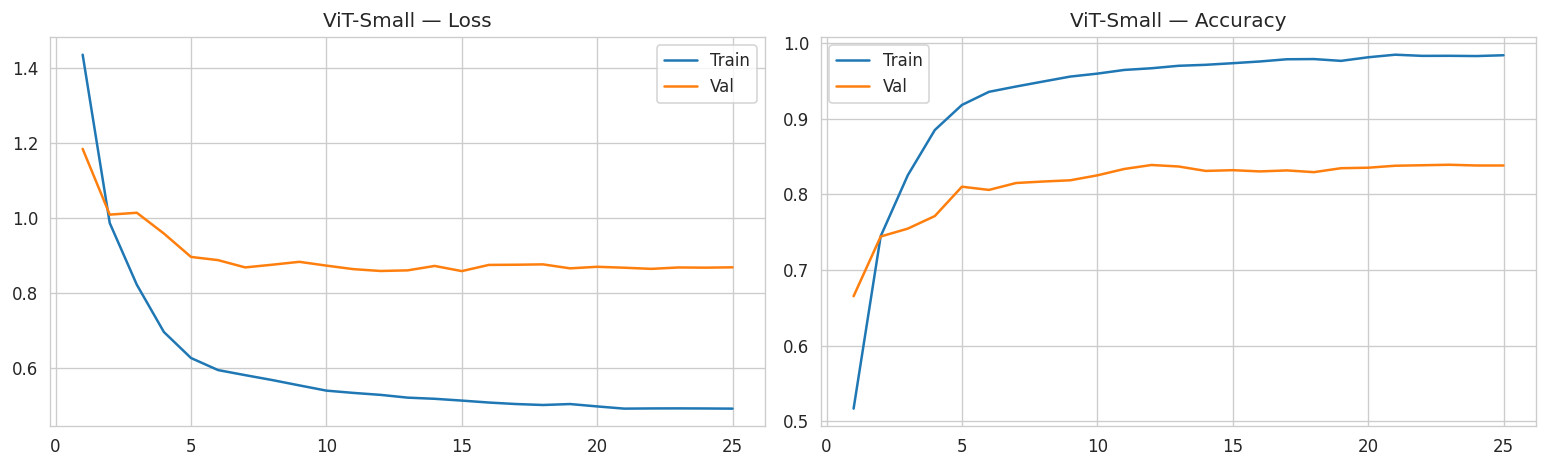

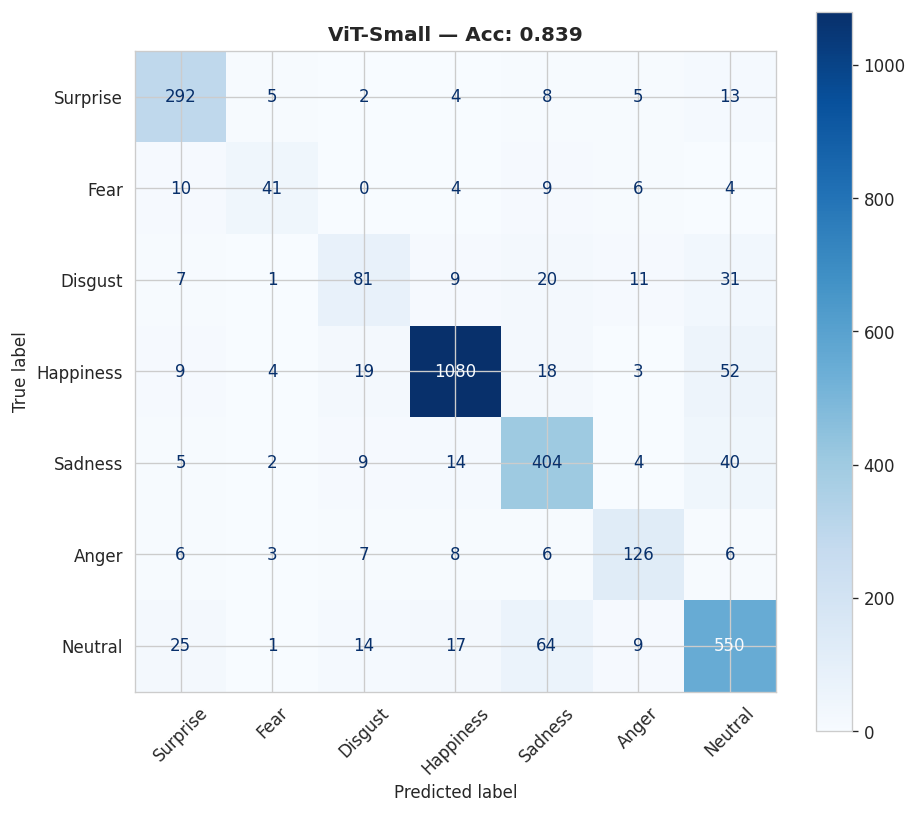

              precision    recall  f1-score   support

    Surprise       0.82      0.89      0.86       329
        Fear       0.72      0.55      0.63        74
     Disgust       0.61      0.51      0.55       160
   Happiness       0.95      0.91      0.93      1185
     Sadness       0.76      0.85      0.80       478
       Anger       0.77      0.78      0.77       162
     Neutral       0.79      0.81      0.80       680

    accuracy                           0.84      3068
   macro avg       0.78      0.76      0.76      3068
weighted avg       0.84      0.84      0.84      3068



In [26]:
plot_history(merge_hist(vit_hist1, vit_hist2), "ViT-Small")
show_confusion(vit, large_test_loader, "ViT-Small");

## Model 7 — Soft Ensemble (ResNet50 + EfficientNetB3 + ViT)

Ensemble weights: ResNet50=0.350 EffNet=0.303 ViT=0.347
Ensemble Accuracy: 0.8615


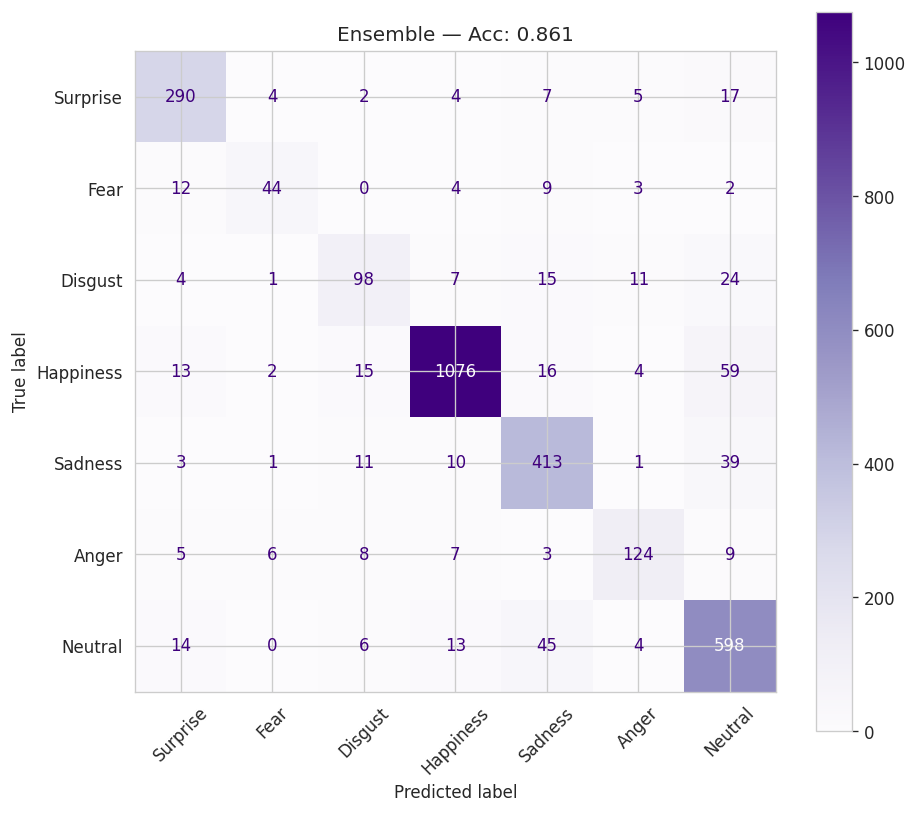

              precision    recall  f1-score   support

    Surprise       0.85      0.88      0.87       329
        Fear       0.76      0.59      0.67        74
     Disgust       0.70      0.61      0.65       160
   Happiness       0.96      0.91      0.93      1185
     Sadness       0.81      0.86      0.84       478
       Anger       0.82      0.77      0.79       162
     Neutral       0.80      0.88      0.84       680

    accuracy                           0.86      3068
   macro avg       0.81      0.79      0.80      3068
weighted avg       0.86      0.86      0.86      3068



In [27]:
@torch.no_grad()
def get_softmax_probs(model, loader):
    model.eval()
    all_probs, all_labels = [], []
    for X, y in loader:
        X = X.to(DEVICE)
        logits = model(X)
        probs  = F.softmax(logits, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_labels.extend(y.numpy())
    return np.vstack(all_probs), np.array(all_labels)

probs_resnet, gt = get_softmax_probs(resnet, large_test_loader)
probs_eff, _     = get_softmax_probs(effnet, large_test_loader)
probs_vit, _     = get_softmax_probs(vit,    large_test_loader)

# Weighted ensemble by individual accuracy
w = np.array([results["ResNet50"], results["EfficientNetB3"], results["ViT-Small"]])
w = w / w.sum()
print(f"Ensemble weights: ResNet50={w[0]:.3f} EffNet={w[1]:.3f} ViT={w[2]:.3f}")

ensemble_probs = w[0]*probs_resnet + w[1]*probs_eff + w[2]*probs_vit
ensemble_preds = ensemble_probs.argmax(axis=1)
ens_acc = accuracy_score(gt, ensemble_preds)
results["Ensemble"] = ens_acc
print(f"Ensemble Accuracy: {ens_acc:.4f}")

cm = confusion_matrix(gt, ensemble_preds)
fig, ax = plt.subplots(figsize=(8, 7))
ConfusionMatrixDisplay(cm, display_labels=CLASSES).plot(ax=ax, cmap="Purples", xticks_rotation=45)
ax.set_title(f"Ensemble — Acc: {ens_acc:.3f}")
plt.tight_layout(); plt.show()
print(classification_report(gt, ensemble_preds, target_names=CLASSES))

---
## 📊 8. Model Comparison

         Model  Val Accuracy    Category
      Ensemble      0.861473    Ensemble
      ResNet50      0.846480 Advanced TL
     ViT-Small      0.838983 Advanced TL
       DeepCNN      0.757823  Normal CNN
EfficientNetB3      0.732399 Advanced TL
     SimpleCNN      0.716428  Normal CNN
       HOG+SVM      0.706649   Classical


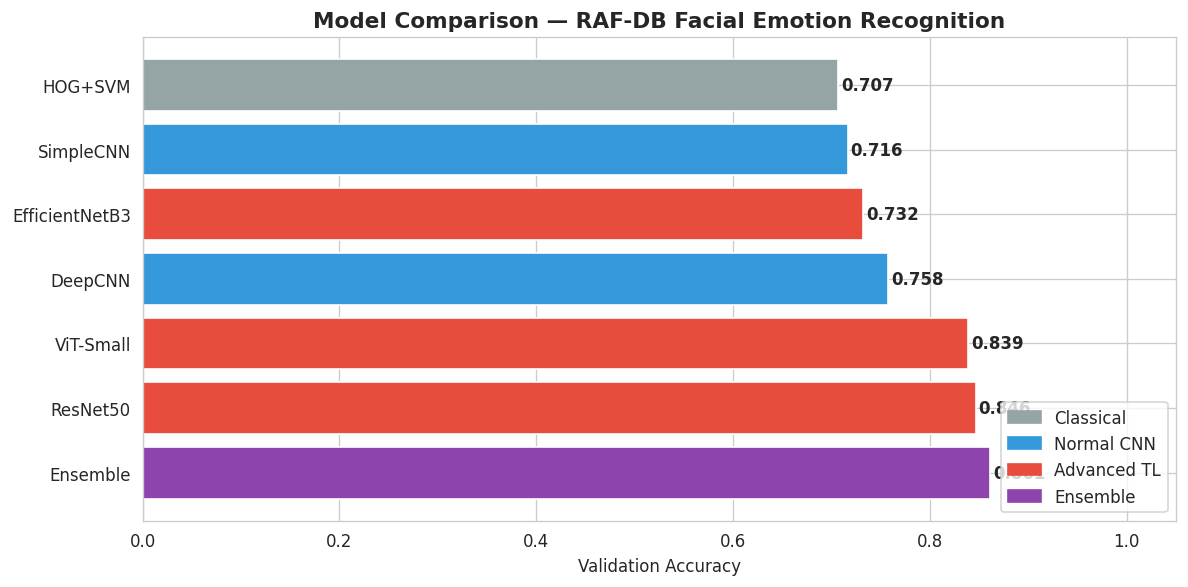

In [28]:
df_results = pd.DataFrame({
    "Model": list(results.keys()),
    "Val Accuracy": list(results.values()),
    "Category": ["Classical", "Normal CNN", "Normal CNN",
                 "Advanced TL", "Advanced TL", "Advanced TL", "Ensemble"]
}).sort_values("Val Accuracy", ascending=False)

print(df_results.to_string(index=False))

palette_map = {"Classical":"#95a5a6", "Normal CNN":"#3498db",
               "Advanced TL":"#e74c3c", "Ensemble":"#8e44ad"}
colors = [palette_map[c] for c in df_results["Category"]]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(df_results["Model"], df_results["Val Accuracy"], color=colors)
for bar, val in zip(bars, df_results["Val Accuracy"]):
    ax.text(bar.get_width() + 0.003, bar.get_y() + bar.get_height()/2,
            f"{val:.3f}", va="center", fontsize=10, fontweight="bold")
ax.set_xlim(0, 1.05)
ax.set_xlabel("Validation Accuracy")
ax.set_title("Model Comparison — RAF-DB Facial Emotion Recognition",
             fontsize=13, fontweight="bold")

from matplotlib.patches import Patch
legend_elems = [Patch(color=v, label=k) for k, v in palette_map.items()]
ax.legend(handles=legend_elems, loc="lower right")
plt.tight_layout(); plt.show()

## 🎯 9. GradCAM Visualization (Best Advanced Model)

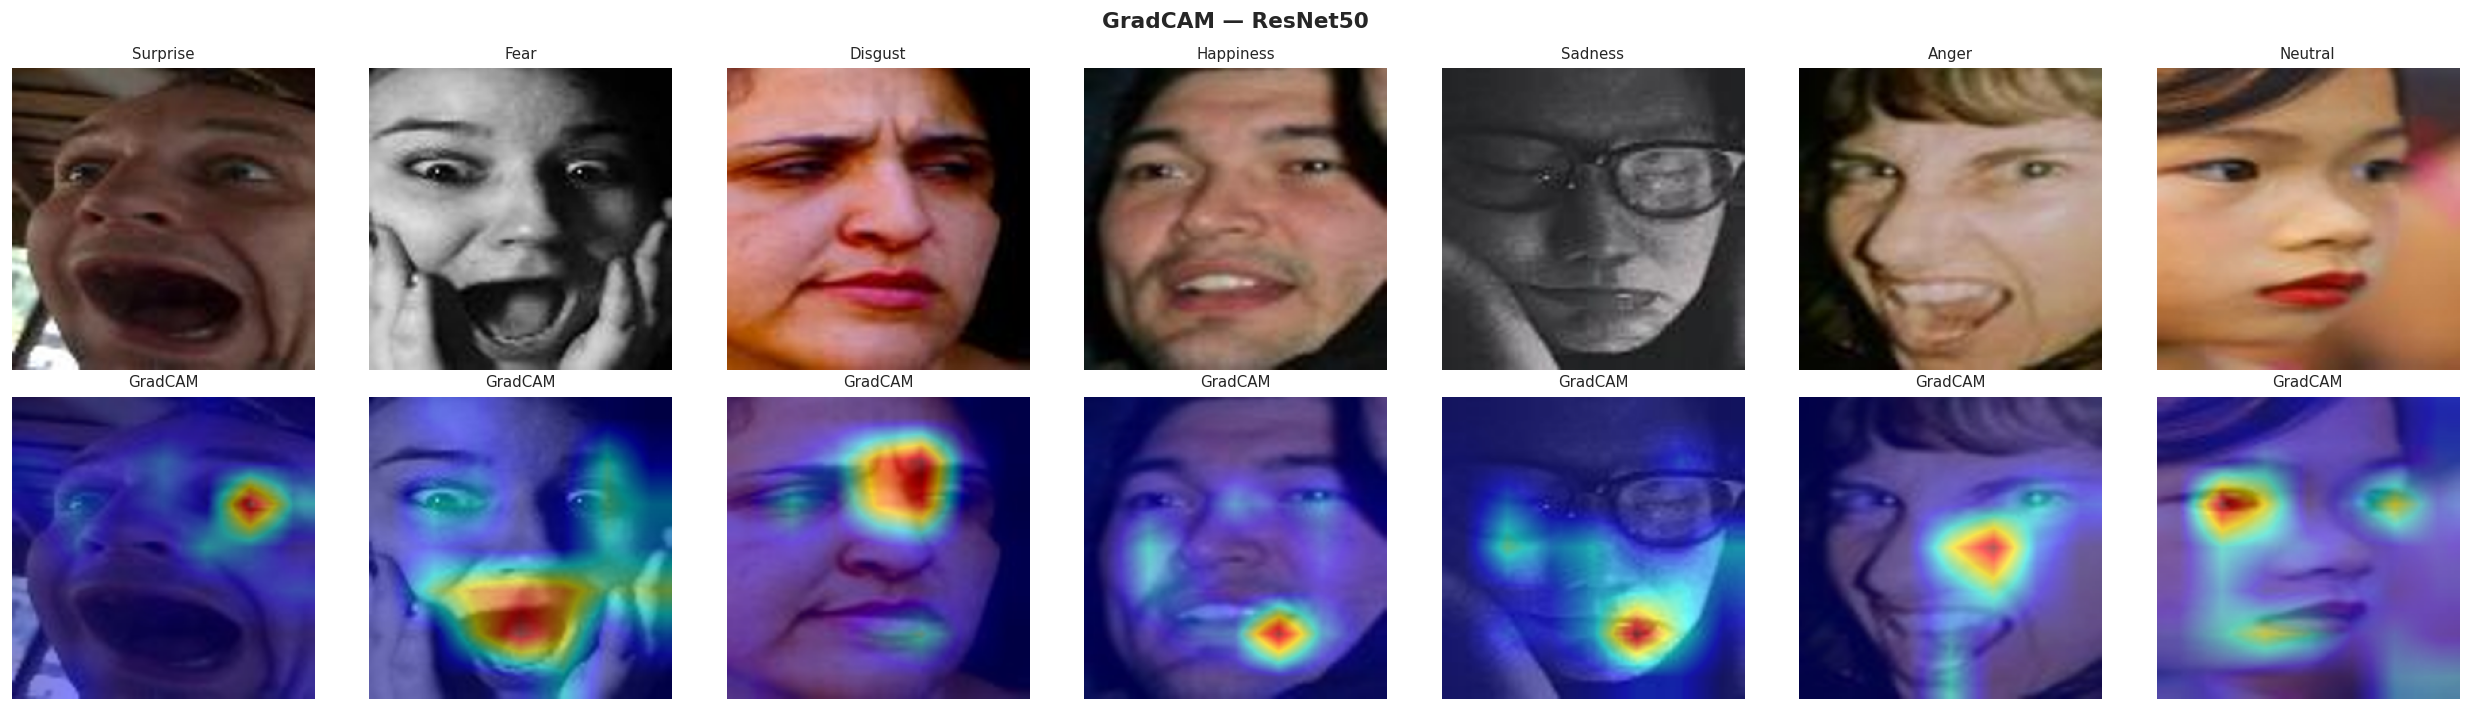

In [29]:
try:
    from pytorch_grad_cam import GradCAM, EigenCAM
    from pytorch_grad_cam.utils.image import show_cam_on_image

    best_adv_name = max(
        {"ResNet50": results["ResNet50"],
         "EfficientNetB3": results["EfficientNetB3"],
         "ViT-Small": results["ViT-Small"]},
        key=lambda k: results[k]
    )
    best_adv = {"ResNet50": resnet, "EfficientNetB3": effnet,
                "ViT-Small": vit}[best_adv_name]

    # Target layer selection
    if best_adv_name == "ResNet50":
        target_layers = [best_adv.layer4[-1]]
        cam = GradCAM(model=best_adv, target_layers=target_layers)
    elif best_adv_name == "EfficientNetB3":
        target_layers = [best_adv.features[-1]]
        cam = GradCAM(model=best_adv, target_layers=target_layers)
    elif best_adv_name == "ViT-Small":
        target_layers = [best_adv.blocks[-1].norm1]
        cam = EigenCAM(model=best_adv, target_layers=target_layers)

    fig, axes = plt.subplots(2, NUM_CLASSES, figsize=(NUM_CLASSES*3, 6))
    for i, (folder_id, emotion) in enumerate(LABEL_MAP.items()):
        p = list((TEST_DIR / folder_id).glob("*.jpg"))[0]
        raw = Image.open(p).convert("RGB").resize((224, 224))
        inp = large_val_tf(raw).unsqueeze(0).to(DEVICE)
        gmap = cam(input_tensor=inp)
        vis  = show_cam_on_image(np.array(raw)/255.0, gmap[0], use_rgb=True)
        axes[0, i].imshow(raw); axes[0, i].set_title(emotion, fontsize=9); axes[0, i].axis("off")
        axes[1, i].imshow(vis); axes[1, i].set_title("GradCAM", fontsize=9); axes[1, i].axis("off")
    plt.suptitle(f"GradCAM — {best_adv_name}", fontsize=13, fontweight="bold")
    plt.tight_layout(); plt.show()
except Exception as e:
    print("GradCAM skipped:", e)

## 💾 10. Save Best Model

In [30]:
model_objects = {
    "ResNet50": resnet, 
    "EfficientNetB3": effnet,
    "ViT-Small": vit, 
    "SimpleCNN": cnn, 
    "DeepCNN": deep_cnn
}

print("Saving all trained models...")
for model_name, model_obj in model_objects.items():
    if model_obj:
        save_path = f"rafdb_model_{model_name.lower().replace('+', '_')}.pth"
        torch.save({
            "model_name": model_name,
            "state_dict": model_obj.state_dict(),
            "classes":    CLASSES,
            "label_map":  LABEL_MAP,
            "accuracy":   results.get(model_name, "N/A") # Get accuracy if available
        }, save_path)
        print(f"Saved: {save_path} (Accuracy: {results.get(model_name, 0.0):.4f})")

print("\n=== Final Leaderboard (RAF-DB) ===")
for name, acc in sorted(results.items(), key=lambda x: -x[1]):
    print(f"  {name:<20} {acc:.4f}")

Saving all trained models...
Saved: rafdb_model_resnet50.pth (Accuracy: 0.8465)
Saved: rafdb_model_efficientnetb3.pth (Accuracy: 0.7324)
Saved: rafdb_model_vit-small.pth (Accuracy: 0.8390)
Saved: rafdb_model_simplecnn.pth (Accuracy: 0.7164)
Saved: rafdb_model_deepcnn.pth (Accuracy: 0.7578)

=== Final Leaderboard (RAF-DB) ===
  Ensemble             0.8615
  ResNet50             0.8465
  ViT-Small            0.8390
  DeepCNN              0.7578
  EfficientNetB3       0.7324
  SimpleCNN            0.7164
  HOG+SVM              0.7066
